# Exploração de Dados

Parágrafo descrevendo

In [144]:
import pandas as pd

In [145]:
df = pd.read_csv('dados_clientes.csv')

In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98872 entries, 0 to 98871
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id_cliente               98872 non-null  object 
 1   idade                    98872 non-null  int64  
 2   genero                   98872 non-null  object 
 3   estado_civil             98872 non-null  object 
 4   tempo_como_cliente       98872 non-null  int64  
 5   tipo_contrato            98872 non-null  object 
 6   forma_pagamento          98872 non-null  object 
 7   suporte_contatado        98872 non-null  int64  
 8   chamados_abertos         98872 non-null  int64  
 9   tempo_medio_atendimento  98872 non-null  float64
 10  reclamacoes              98872 non-null  int64  
 11  atrasos_pagamento        98872 non-null  int64  
 12  renda_faixa              98872 non-null  object 
 13  servicos_assinados       98872 non-null  int64  
 14  produtos_assinados    

In [147]:
df.head()

,id_cliente,idade,genero,estado_civil,tempo_como_cliente,tipo_contrato,forma_pagamento,suporte_contatado,chamados_abertos,tempo_medio_atendimento,reclamacoes,atrasos_pagamento,renda_faixa,servicos_assinados,produtos_assinados,valor_mensal,total_gasto,churn
0,c19f9c98-53b9-4332-bc13-5ef6140340bf,44,Feminino,Solteiro,53,Mensal,Cartão,3,0,27.13,0,1,5000-10000,1,['Produto B'],92.50,5008.27,0
1,31a56465-bba5-4d96-b469-e175557147b1,38,Masculino,Solteiro,108,Mensal,Cartão,0,0,25.33,1,2,10000-50000,2,['Produto A' 'Produto B'],154.26,17019.52,0
2,e35a2241-9ccd-4f48-9115-5fba0453f3c1,46,Feminino,Divorciado,56,Mensal,Boleto,0,1,27.43,2,3,1000-5000,1,['Produto E'],202.58,11589.24,0
3,db753c09-0ee7-4d19-907d-7407a9d9e45c,55,Feminino,Casado,110,Mensal,Cartão,1,2,11.50,2,3,5000-10000,1,['Produto F'],344.72,38737.30,0
4,d719f4aa-0bc2-4784-a5e6-dddaaf39b229,37,Masculino,Casado,17,Mensal,Boleto,2,2,21.42,0,2,5000-10000,5,['Produto C' 'Produto B' 'Produto D' 'Produto E' 'Produto F'],871.10,15128.20,1


In [148]:
df.describe()

,idade,tempo_como_cliente,suporte_contatado,chamados_abertos,tempo_medio_atendimento,reclamacoes,atrasos_pagamento,servicos_assinados,valor_mensal,total_gasto,churn
count,98872.000000,98872.000000,98872.000000,98872.000000,98872.000000,98872.000000,98872.000000,98872.000000,98872.000000,98872.000000,98872.000000
mean,39.512228,60.366868,2.001315,0.993911,17.554497,0.500617,2.006210,2.566399,427.770373,26390.939257,0.336961
std,10.011932,34.714797,1.413176,0.995506,7.207768,0.707253,1.412597,1.562001,286.159677,25442.470904,0.472674
min,-4.000000,1.000000,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,33.000000,30.000000,1.000000,0.000000,11.320000,0.000000,1.000000,1.000000,210.667500,6214.635000,0.000000
50%,40.000000,60.000000,2.000000,1.000000,17.570000,0.000000,2.000000,2.000000,391.090000,19058.830000,0.000000
75%,46.000000,91.000000,3.000000,2.000000,23.810000,1.000000,3.000000,4.000000,629.232500,39222.430000,1.000000
max,84.000000,120.000000,10.000000,8.000000,30.000000,5.000000,4.000000,6.000000,1199.800000,146078.270000,1.000000


In [149]:
df['estado_civil'].value_counts()

estado_civil
Casado        39605
Solteiro      39562
Divorciado    19705
Name: count, dtype: int64

In [150]:
df['forma_pagamento'].value_counts()

forma_pagamento
Boleto    49409
Cartão    29597
Débito    19866
Name: count, dtype: int64

In [151]:
df['tipo_contrato'].value_counts()

tipo_contrato
Mensal    69233
Anual     29639
Name: count, dtype: int64

In [152]:
df['genero'].value_counts()

genero
Feminino     49605
Masculino    49267
Name: count, dtype: int64

In [153]:
df['renda_faixa'].value_counts()

renda_faixa
1000-5000       38237
5000-10000      23460
10000-50000     22601
0-1000          14365
50000-100000      209
Name: count, dtype: int64

Necessidade de categorização de faixas de idade

Necessidade de retirar id_cliente

Necessidade de categorização de forma_pagamento

Necessidade de categorização de tipo_contrato

Necessidade de categorização de genero

Necessidade de categorização de estado_civil

Necessidade de categorização de renda_faixa

Necessidade de normalizar

Necessidade de fazer one hot enconding com a coluna de produtos_assinados

In [154]:
import numpy as np

colunas_numericas = df.select_dtypes(include=np.number).columns.tolist()
correlacao = df[colunas_numericas].corr()

correlacao_flatten = correlacao.unstack()
correlacao_flatten = correlacao_flatten[correlacao_flatten < 1.0]
top_corr = correlacao_flatten.abs().sort_values(ascending=False).head(10)
print("Top 5 correlações mais fortes:")
for (col1, col2), valor in top_corr.items():
    print(f"{col1} × {col2}: {valor:.3f}")

Top 5 correlações mais fortes:
valor_mensal × servicos_assinados: 0.911
servicos_assinados × valor_mensal: 0.911
total_gasto × valor_mensal: 0.696
valor_mensal × total_gasto: 0.696
total_gasto × servicos_assinados: 0.634
servicos_assinados × total_gasto: 0.634
tempo_como_cliente × total_gasto: 0.597
total_gasto × tempo_como_cliente: 0.597
churn × tempo_como_cliente: 0.328
tempo_como_cliente × churn: 0.328


In [155]:
print("\n=== ANÁLISE DE VARIÁVEIS CATEGÓRICAS ===")
colunas_categoricas = ['genero', 'estado_civil', 'tipo_contrato', 'forma_pagamento', 'renda_faixa']
for coluna in colunas_categoricas:
    print(f"\nDistribuição de {coluna}:")
    contagem = df[coluna].value_counts()
    percentual = df[coluna].value_counts(normalize=True) * 100
    for valor, count in contagem.items():
        print(f"  {valor}: {count} ({percentual[valor]:.1f}%)")
    
    # Análise de churn por categoria
    print(f"Taxa de churn por {coluna}:")
    churn_by_cat = df.groupby(coluna)['churn'].mean() * 100
    for cat, taxa in churn_by_cat.items():
        print(f"  {cat}: {taxa:.1f}%")


=== ANÁLISE DE VARIÁVEIS CATEGÓRICAS ===

Distribuição de genero:
  Feminino: 49605 (50.2%)
  Masculino: 49267 (49.8%)
Taxa de churn por genero:
  Feminino: 34.0%
  Masculino: 33.4%

Distribuição de estado_civil:
  Casado: 39605 (40.1%)
  Solteiro: 39562 (40.0%)
  Divorciado: 19705 (19.9%)
Taxa de churn por estado_civil:
  Casado: 34.8%
  Divorciado: 32.9%
  Solteiro: 32.9%

Distribuição de tipo_contrato:
  Mensal: 69233 (70.0%)
  Anual: 29639 (30.0%)
Taxa de churn por tipo_contrato:
  Anual: 31.6%
  Mensal: 34.6%

Distribuição de forma_pagamento:
  Boleto: 49409 (50.0%)
  Cartão: 29597 (29.9%)
  Débito: 19866 (20.1%)
Taxa de churn por forma_pagamento:
  Boleto: 33.6%
  Cartão: 34.2%
  Débito: 33.2%

Distribuição de renda_faixa:
  1000-5000: 38237 (38.7%)
  5000-10000: 23460 (23.7%)
  10000-50000: 22601 (22.9%)
  0-1000: 14365 (14.5%)
  50000-100000: 209 (0.2%)
Taxa de churn por renda_faixa:
  0-1000: 34.2%
  1000-5000: 32.6%
  10000-50000: 34.6%
  5000-10000: 34.3%
  50000-100000: 36

In [156]:
print("\n=== ANÁLISE DE OUTLIERS ===")
for coluna in ['idade', 'tempo_como_cliente', 'valor_mensal', 'total_gasto']:
    q1 = df[coluna].quantile(0.25)
    q3 = df[coluna].quantile(0.75)
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    outliers = df[(df[coluna] < limite_inf) | (df[coluna] > limite_sup)]
    
    if not outliers.empty:
        print(f"Outliers em {coluna}: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
        print(f"  Mínimo: {df[coluna].min()}, Máximo: {df[coluna].max()}")
        print(f"  Limites para outliers: {limite_inf:.2f} a {limite_sup:.2f}")



=== ANÁLISE DE OUTLIERS ===
Outliers em idade: 929 (0.9%)
  Mínimo: -4, Máximo: 84
  Limites para outliers: 13.50 a 65.50
Outliers em total_gasto: 3056 (3.1%)
  Mínimo: 0.0, Máximo: 146078.27
  Limites para outliers: -43297.06 a 88734.12


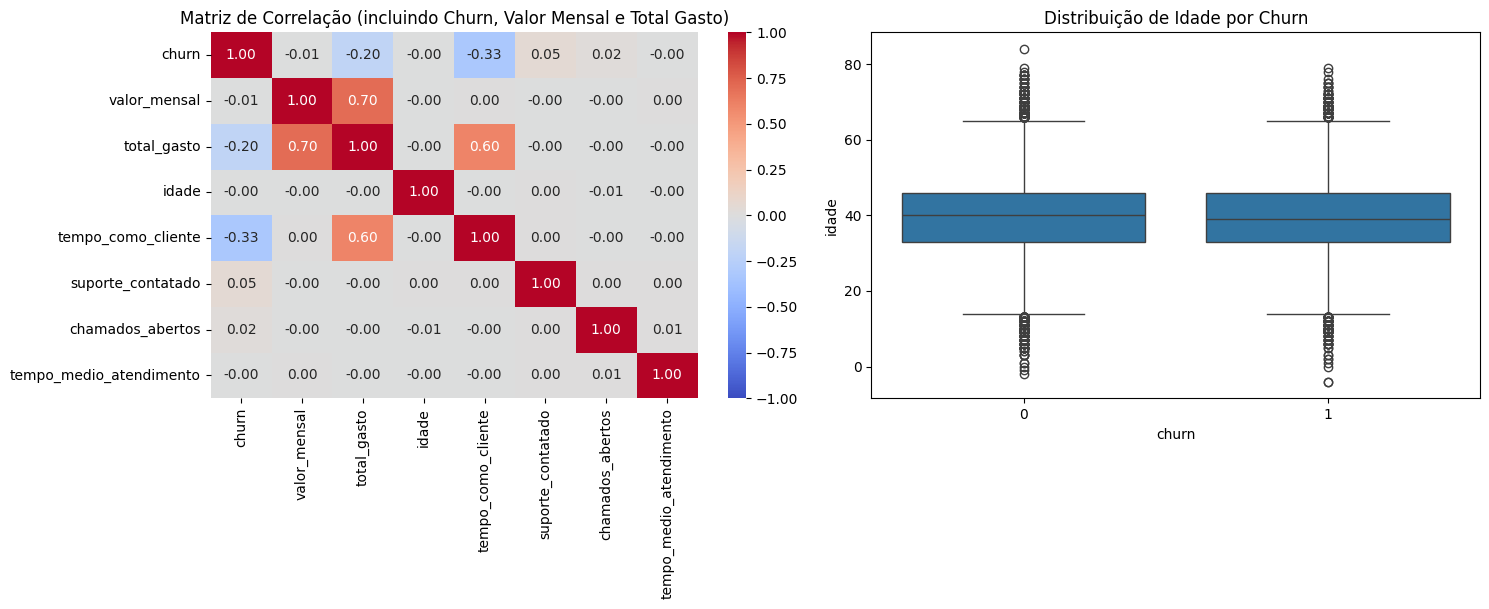

In [157]:
import matplotlib.pyplot as plt
import seaborn as sns

def criar_visualizacoes():
    # Selecionar as colunas desejadas para a matriz de correlação
    colunas_para_correlacao = [
        'churn',
        'valor_mensal',
        'total_gasto'
    ]
    # Adicione mais colunas numéricas relevantes se desejar
    outras_colunas = [col for col in df.select_dtypes(include=['number']).columns 
                      if col not in colunas_para_correlacao]
    # Limite a 5 outras colunas para não ficar muito grande
    colunas_para_heatmap = colunas_para_correlacao + outras_colunas[:5]
    
    # Calcular a matriz de correlação
    correlacao = df[colunas_para_heatmap].corr()
    
    plt.figure(figsize=(15, 10))
    
    # Gráfico 1: Correlação
    plt.subplot(2, 2, 1)
    sns.heatmap(
        correlacao, 
        annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f"
    )
    plt.title('Matriz de Correlação (incluindo Churn, Valor Mensal e Total Gasto)')
    
    # Gráfico 2: Distribuição de idade por churn
    plt.subplot(2, 2, 2)
    sns.boxplot(x='churn', y='idade', data=df)
    plt.title('Distribuição de Idade por Churn')
   
    plt.tight_layout()
    plt.show()

criar_visualizacoes()


# Pré-processamento

In [158]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['estado_civil'] = le.fit_transform(df['estado_civil'])
df['forma_pagamento'] = le.fit_transform(df['forma_pagamento'])
df['tipo_contrato'] = le.fit_transform(df['tipo_contrato'])
df['genero'] = le.fit_transform(df['genero'])

In [159]:
faixas_ordenadas = ['0-1000', '1000-5000', '5000-10000', '10000-50000', '50000-100000']
df['renda_faixa'] = pd.Categorical(df['renda_faixa'], categories=faixas_ordenadas, ordered=True)
df['renda_faixa'] = df['renda_faixa'].cat.codes


In [160]:
print("10 menores idades:")
print(df['idade'].sort_values().head(10))

print("\n10 maiores idades:")
print(df['idade'].sort_values(ascending=False).head(10))

10 menores idades:
75586   -4
32541   -4
43650   -2
59759   -1
9770     0
74712    0
19674    1
71722    1
8200     1
65425    2
Name: idade, dtype: int64

10 maiores idades:
15843    84
18851    79
2895     79
209      78
86882    78
89937    77
52813    77
87015    77
33320    77
96425    77
Name: idade, dtype: int64


In [161]:
df = df[df['idade'] >= 18]

In [162]:
bins = [17, 30, 50, 70, float('inf')]
labels = [1, 2, 3, 4]  # 1: 18-30, 2: 31-50, etc.
df['idade'] = pd.cut(df['idade'], bins=bins, labels=labels)
df['idade'] = df['idade'].astype(int)

In [163]:
produtos = ['Produto A', 'Produto B', 'Produto C', 'Produto D', 'Produto E', 'Produto F']


In [164]:
df['produtos_assinados'] = df['produtos_assinados'].astype(str)


In [165]:
for produto in produtos:
    coluna = f"produto_{produto[-1].lower()}"
    df[coluna] = df['produtos_assinados'].apply(lambda x: 1 if produto in x else 0)


In [166]:
print(df[['id_cliente'] + [f"produto_{p[-1].lower()}" for p in produtos]].head())


                             id_cliente  produto_a  produto_b  produto_c  produto_d  produto_e  produto_f
0  c19f9c98-53b9-4332-bc13-5ef6140340bf          0          1          0          0          0          0
1  31a56465-bba5-4d96-b469-e175557147b1          1          1          0          0          0          0
2  e35a2241-9ccd-4f48-9115-5fba0453f3c1          0          0          0          0          1          0
3  db753c09-0ee7-4d19-907d-7407a9d9e45c          0          0          0          0          0          1
4  d719f4aa-0bc2-4784-a5e6-dddaaf39b229          0          1          1          1          1          1


In [167]:
df.drop(columns=['produtos_assinados'], inplace=True)


In [168]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
colunas_numericas = df.select_dtypes(include=['float64', 'int64']).columns

df_zscore = df.copy()
df_zscore[colunas_numericas] = scaler.fit_transform(df[colunas_numericas])


In [169]:
df.describe()

,idade,genero,estado_civil,tempo_como_cliente,tipo_contrato,forma_pagamento,suporte_contatado,chamados_abertos,tempo_medio_atendimento,reclamacoes,atrasos_pagamento,renda_faixa,servicos_assinados,valor_mensal,total_gasto,churn,produto_a,produto_b,produto_c,produto_d,produto_e,produto_f
count,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000
mean,1.967279,0.498605,0.999292,60.359442,0.700574,0.701292,2.001487,0.993917,17.557247,0.500082,2.006370,1.555606,2.567135,427.838123,26393.383713,0.337009,0.427152,0.427398,0.429429,0.427295,0.428700,0.427162
std,0.559167,0.500001,0.894907,34.708981,0.458009,0.782062,1.414122,0.995468,7.207013,0.706700,1.412323,1.004003,1.562306,286.215832,25445.671456,0.472690,0.494667,0.494703,0.494997,0.494688,0.494893,0.494669
min,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,30.000000,0.000000,0.000000,1.000000,0.000000,11.320000,0.000000,1.000000,1.000000,1.000000,210.560000,6213.315000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,0.000000,1.000000,60.000000,1.000000,1.000000,2.000000,1.000000,17.570000,0.000000,2.000000,1.000000,2.000000,391.195000,19053.270000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.000000,1.000000,2.000000,90.750000,1.000000,1.000000,3.000000,2.000000,23.810000,1.000000,3.000000,2.000000,4.000000,629.350000,39233.315000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,4.000000,1.000000,2.000000,120.000000,1.000000,2.000000,10.000000,8.000000,30.000000,5.000000,4.000000,4.000000,6.000000,1199.800000,146078.270000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [170]:
pd.set_option('display.max_columns', None)   # Mostrar todas as colunas
pd.set_option('display.max_colwidth', None)   # Mostrar todo o conteúdo das células
pd.set_option('display.expand_frame_repr', False)  # Não quebrar o DataFrame em várias linhas

# Agora o head normal vai mostrar tudo
print(df.head())

                             id_cliente  idade  genero  estado_civil  tempo_como_cliente  tipo_contrato  forma_pagamento  suporte_contatado  chamados_abertos  tempo_medio_atendimento  reclamacoes  atrasos_pagamento  renda_faixa  servicos_assinados  valor_mensal  total_gasto  churn  produto_a  produto_b  produto_c  produto_d  produto_e  produto_f
0  c19f9c98-53b9-4332-bc13-5ef6140340bf      2       0             2                  53              1                1                  3                 0                    27.13            0                  1            2                   1         92.50      5008.27      0          0          1          0          0          0          0
1  31a56465-bba5-4d96-b469-e175557147b1      2       1             2                 108              1                1                  0                 0                    25.33            1                  2            3                   2        154.26     17019.52      0          1          1 

In [171]:
df.drop(columns=['id_cliente'], inplace=True)

In [172]:
df.head()

,idade,genero,estado_civil,tempo_como_cliente,tipo_contrato,forma_pagamento,suporte_contatado,chamados_abertos,tempo_medio_atendimento,reclamacoes,atrasos_pagamento,renda_faixa,servicos_assinados,valor_mensal,total_gasto,churn,produto_a,produto_b,produto_c,produto_d,produto_e,produto_f
0,2,0,2,53,1,1,3,0,27.13,0,1,2,1,92.50,5008.27,0,0,1,0,0,0,0
1,2,1,2,108,1,1,0,0,25.33,1,2,3,2,154.26,17019.52,0,1,1,0,0,0,0
2,2,0,1,56,1,0,0,1,27.43,2,3,1,1,202.58,11589.24,0,0,0,0,0,1,0
3,3,0,0,110,1,1,1,2,11.50,2,3,2,1,344.72,38737.30,0,0,0,0,0,0,1
4,2,1,0,17,1,0,2,2,21.42,0,2,2,5,871.10,15128.20,1,0,1,1,1,1,1


Fazer a tabela de correlação de novo

In [177]:
colunas_numericas = df.select_dtypes(include=np.number).columns.tolist()
correlacao = df[colunas_numericas].corr()

correlacao_flatten = correlacao.unstack()
correlacao_flatten = correlacao_flatten[correlacao_flatten < 1.0]
top_corr = correlacao_flatten.abs().sort_values(ascending=False).head(20)
print("Top 5 correlações mais fortes:")
for (col1, col2), valor in top_corr.items():
    print(f"{col1} × {col2}: {valor:.3f}")

Top 5 correlações mais fortes:
servicos_assinados × valor_mensal: 0.911
valor_mensal × servicos_assinados: 0.911
valor_mensal × total_gasto: 0.696
total_gasto × valor_mensal: 0.696
produto_f × valor_mensal: 0.681
valor_mensal × produto_f: 0.681
total_gasto × servicos_assinados: 0.634
servicos_assinados × total_gasto: 0.634
produto_e × valor_mensal: 0.604
valor_mensal × produto_e: 0.604
tempo_como_cliente × total_gasto: 0.597
total_gasto × tempo_como_cliente: 0.597
produto_d × valor_mensal: 0.532
valor_mensal × produto_d: 0.532
produto_f × servicos_assinados: 0.529
servicos_assinados × produto_f: 0.529
servicos_assinados × produto_d: 0.527
produto_d × servicos_assinados: 0.527
produto_a × servicos_assinados: 0.527
servicos_assinados × produto_a: 0.527


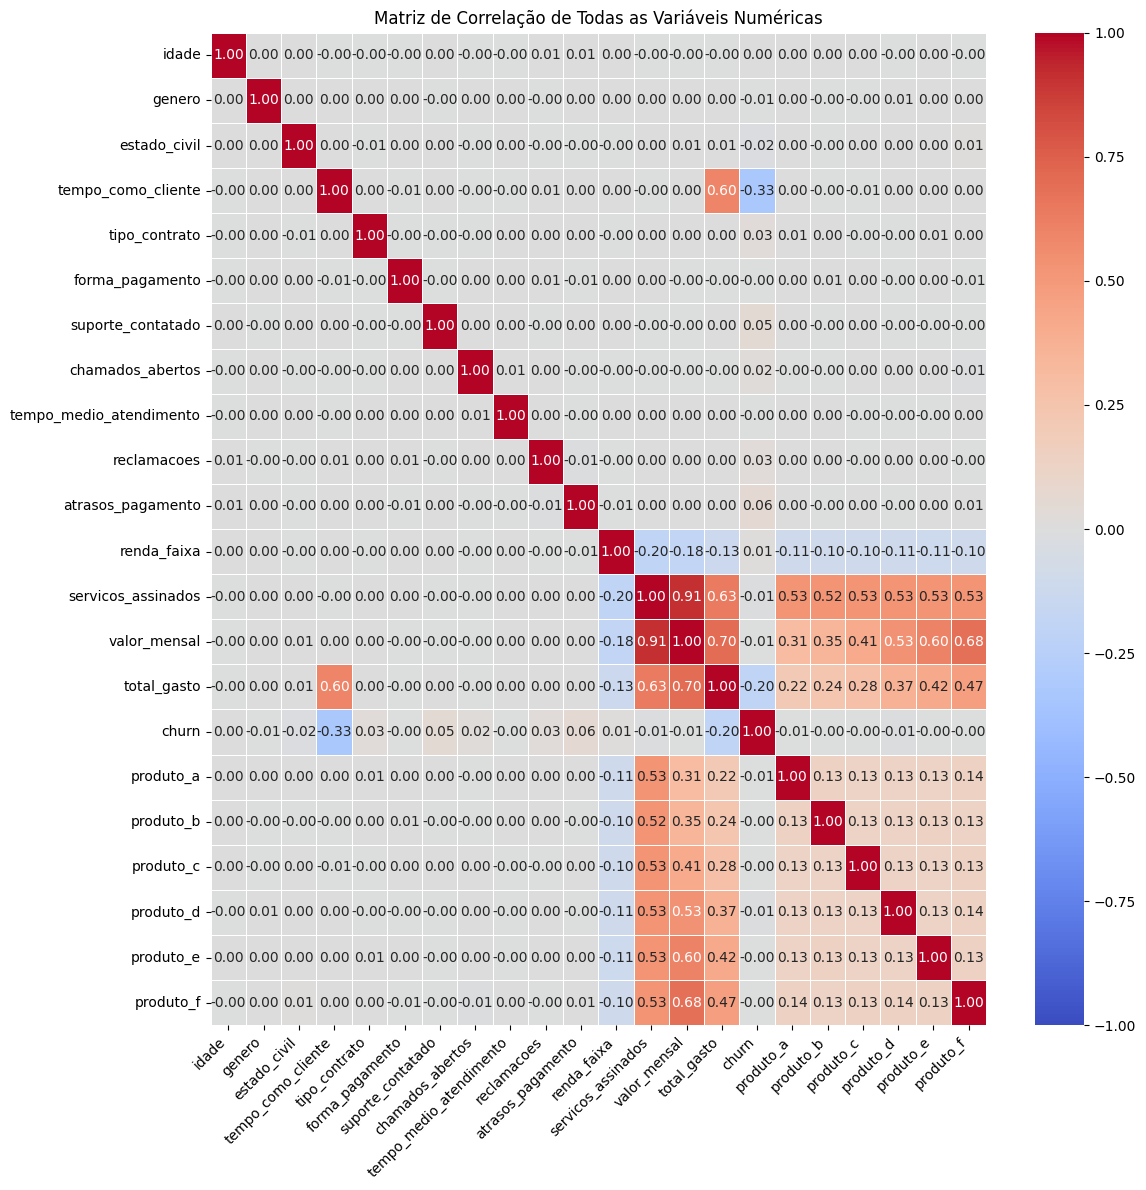

In [180]:
import matplotlib.pyplot as plt
import seaborn as sns

def criar_visualizacoes():
    # Selecionar apenas colunas numéricas para a matriz de correlação
    colunas_numericas = df.select_dtypes(include=['number']).columns
    
    # Calcular a matriz de correlação com todas as colunas numéricas
    correlacao = df[colunas_numericas].corr()
    
    # Definir o tamanho da figura com base na quantidade de colunas
    tamanho_figura = max(12, len(colunas_numericas) / 2)
    
    plt.figure(figsize=(tamanho_figura, tamanho_figura))
    
    # Criar o heatmap de correlação
    sns.heatmap(
        correlacao, 
        annot=True, 
        cmap='coolwarm', 
        vmin=-1, 
        vmax=1, 
        fmt=".2f",
        linewidths=0.5
    )
    plt.title('Matriz de Correlação de Todas as Variáveis Numéricas')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

criar_visualizacoes()

In [175]:
df['idade'].value_counts()

idade
2    67174
1    16798
3    13428
4       90
Name: count, dtype: int64

In [178]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 97490 entries, 0 to 98871
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   idade                    97490 non-null  int64  
 1   genero                   97490 non-null  int64  
 2   estado_civil             97490 non-null  int64  
 3   tempo_como_cliente       97490 non-null  int64  
 4   tipo_contrato            97490 non-null  int64  
 5   forma_pagamento          97490 non-null  int64  
 6   suporte_contatado        97490 non-null  int64  
 7   chamados_abertos         97490 non-null  int64  
 8   tempo_medio_atendimento  97490 non-null  float64
 9   reclamacoes              97490 non-null  int64  
 10  atrasos_pagamento        97490 non-null  int64  
 11  renda_faixa              97490 non-null  int8   
 12  servicos_assinados       97490 non-null  int64  
 13  valor_mensal             97490 non-null  float64
 14  total_gasto              97

In [179]:
df.head()

,idade,genero,estado_civil,tempo_como_cliente,tipo_contrato,forma_pagamento,suporte_contatado,chamados_abertos,tempo_medio_atendimento,reclamacoes,atrasos_pagamento,renda_faixa,servicos_assinados,valor_mensal,total_gasto,churn,produto_a,produto_b,produto_c,produto_d,produto_e,produto_f
0,2,0,2,53,1,1,3,0,27.13,0,1,2,1,92.50,5008.27,0,0,1,0,0,0,0
1,2,1,2,108,1,1,0,0,25.33,1,2,3,2,154.26,17019.52,0,1,1,0,0,0,0
2,2,0,1,56,1,0,0,1,27.43,2,3,1,1,202.58,11589.24,0,0,0,0,0,1,0
3,3,0,0,110,1,1,1,2,11.50,2,3,2,1,344.72,38737.30,0,0,0,0,0,0,1
4,2,1,0,17,1,0,2,2,21.42,0,2,2,5,871.10,15128.20,1,0,1,1,1,1,1


# Hipóteses

## Hipótese 1

quem tem maiores gastos mensais cancelam mais

## Hipótese 2

quem tem mais reclamações cancelam mais

## Hipótese 3

quem tem mais tempo como cliente canela menos

# Modelo

In [176]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import OneHotEncoder

# Separar features e target
X = df.drop('churn', axis=1)
y = df['churn']

# Identificar colunas categóricas
categorical_cols = X.select_dtypes(include=['object']).columns

# Aplicar OneHotEncoder nas categóricas
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42)

# Treinar Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Prever no teste
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

# Avaliação
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


KeyboardInterrupt: 

Engenharia de features

Encontrar melhores parâmetros através de grid search

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt']
}


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,           # ou 5, dependendo do tamanho do dataset
    n_jobs=-1,      # usa todos os núcleos disponíveis
    verbose=2,
    scoring='accuracy'  # ou 'f1', 'roc_auc', etc.
)


In [ ]:
grid_search.fit(X_train, y_train)


print("Melhores hiperparâmetros:", grid_search.best_params_)
print("Melhor score na validação cruzada:", grid_search.best_score_)


Fitting 3 folds for each of 216 candidates, totalling 648 fits


KeyboardInterrupt: 

Testagem de diferentes modelos

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score


# Use os melhores hiperparâmetros encontrados
best_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    max_features='sqrt',
    min_samples_leaf=4,
    min_samples_split=10,
    random_state=42
)

# Treine o modelo com TODO o conjunto de treino
best_rf.fit(X_train, y_train)


# Faça previsões
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

# Avaliação
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.75      0.88      0.81     19617
           1       0.64      0.41      0.50     10045

    accuracy                           0.72     29662
   macro avg       0.69      0.65      0.65     29662
weighted avg       0.71      0.72      0.70     29662

ROC-AUC: 0.6958434762384582


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Aplicar SMOTE para balancear as classes no conjunto de treino
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

# Treinar o Random Forest com os melhores hiperparâmetros e class_weight='balanced'
best_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    max_features='sqrt',
    min_samples_leaf=4,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42
)
best_rf.fit(X_res, y_res)

# Fazer previsões no conjunto de teste
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

# Avaliar resultados
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.76      0.82      0.79     19617
           1       0.58      0.49      0.53     10045

    accuracy                           0.71     29662
   macro avg       0.67      0.65      0.66     29662
weighted avg       0.70      0.71      0.70     29662

ROC-AUC: 0.6855040070105081


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)

y_pred_logreg = logreg.predict(X_test)
y_proba_logreg = logreg.predict_proba(X_test)[:, 1]

print("Regressão Logística")
print(classification_report(y_test, y_pred_logreg))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_logreg))


Regressão Logística
              precision    recall  f1-score   support

           0       0.79      0.65      0.72     19617
           1       0.49      0.66      0.56     10045

    accuracy                           0.66     29662
   macro avg       0.64      0.66      0.64     29662
weighted avg       0.69      0.66      0.66     29662

ROC-AUC: 0.7042704323382623


c:\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum()/(y_train == 1).sum(),  # balanceamento
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))


c:\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:30:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost
              precision    recall  f1-score   support

           0       0.77      0.77      0.77     19617
           1       0.55      0.55      0.55     10045

    accuracy                           0.69     29662
   macro avg       0.66      0.66      0.66     29662
weighted avg       0.69      0.69      0.69     29662

ROC-AUC: 0.6931068285187472
